In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Load your Pangu-Weather file
ds = xr.open_dataset('output_surface_2011-04-28-00-00.nc')

# Use the full names 'latitude' and 'longitude'
subset = ds.sel(
    latitude=slice(40, 30),   # Pangu often goes North to South (90 to -90)
    longitude=slice(265, 280) # Pangu usually uses 0-360 convention
)

subset.to_netcdf('regional_surface_2011-04-28-00-00.nc')

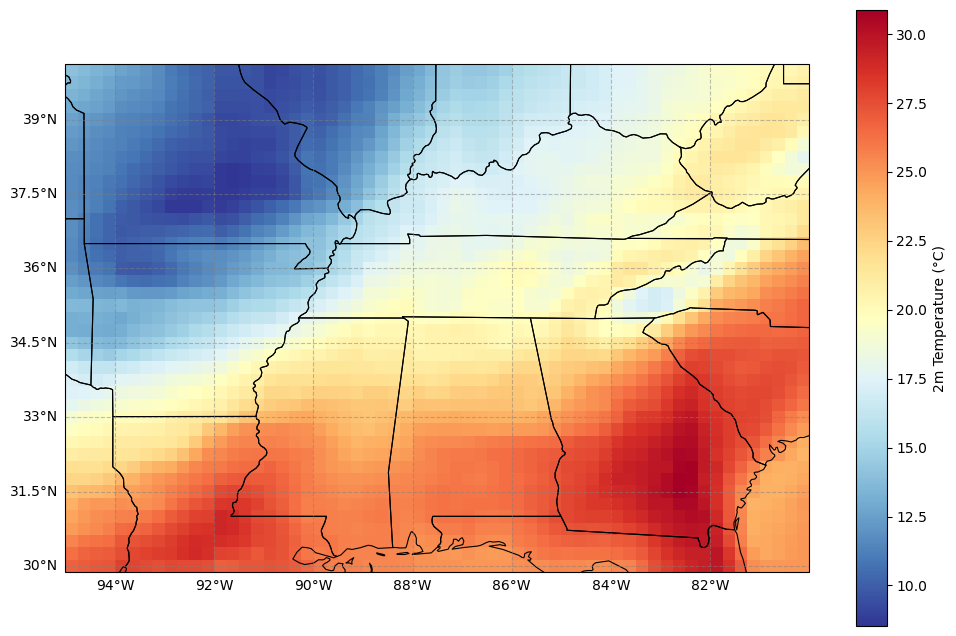

In [2]:

ds = xr.open_dataset('regional_surface_2011-04-28-00-00.nc')

# 1. Handle the 'time' dimension safely
if 'time' in ds.dims:
    t2m_raw = ds['temperature_2m'].isel(time=0)
elif 'valid_time' in ds.dims:
    t2m_raw = ds['temperature_2m'].isel(valid_time=0)
else:
    t2m_raw = ds['temperature_2m']

t2m = t2m_raw - 273.15

# 2. Fix Longitude for Cartopy (-180 to 180)
if ds.longitude.max() > 180:
    ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
    ds = ds.sortby('longitude')

# 3. Setup Plot
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add unzipped states
shp_path = 'state_lines/ne_50m_admin_1_states_provinces.shp'
reader = shpreader.Reader(shp_path)
ax.add_geometries(reader.geometries(), ccrs.PlateCarree(), 
                  facecolor='none', edgecolor='black', linewidth=0.8)

# 4. Plot
t2m.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdYlBu_r',
         cbar_kwargs={'label': '2m Temperature (°C)'})

# --- MATCHING WRF-STYLE TWO-SIDED LABELS ---
# dms=True gives you the 92°30'W style 
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  linestyle='--', color='gray', alpha=0.5)

# Limit to two sides (Bottom and Left)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

# Format with geographic symbols (°N/°W)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

#plt.title("Pangu-Weather 2m Temperature (April 2011)")
#plt.savefig('pangu_2mtemp_April_27_2011.png', dpi=300, bbox_inches='tight')
plt.show()